## Implementing gradient descent to find a local minimum of a function

In [1]:
#Libraries
import numpy as np
import matplotlib.pylab as plt
import pandas as pd
import sys
import os

from importlib import reload

sys.path.append(os.path.abspath("../src"))
import linear_regression
from linear_regression import SimpleLinearRegression
reload(linear_regression)

<module 'linear_regression' from 'd:\\Studying\\Machine Learning\\ML Projects\\linear-regression\\src\\linear_regression.py'>

Function: $f(x) = 2x^2 - 3x + 5$

In [2]:
def f(x):
    return 2*x**2 - 3*x + 5

Derivative: $\frac{df}{dx} = 4x - 3$

In [3]:
def df(x):
    return 4*x - 3

Gradient Descent formula:
$x_{\text{new}} = x_{\text{old}} - \alpha \cdot \frac{df}{dx}$.

Where $\alpha$ is the learning rate, $x_{\text{new}}$ is the current value of $x$ or the value of the previous iteration and $x_{\text{new}}$ is our updated value of $x$ after taking a step along the gradient of the function.

In [ ]:
def gradient_descent(x: float, lr: float, iter: int): 
    for i in range(iter): #for every iteration
        x = x - lr*df(x) #update x
        if (i + 1) % 10 == 0: # print every 10 iterations
            print(f"Iter {i+1}:  x = {x}, f(x) = {f(x)}")
    return x

In [11]:
minimum = gradient_descent(0, 0.03, 100)

Iter 10:  x = 0.5411242679929484, f(x) = 3.9622581428429635
Iter 20:  x = 0.6918279047713578, f(x) = 3.8817679853265803
Iter 30:  x = 0.7337990147023112, f(x) = 3.875524943849232
Iter 40:  x = 0.7454880097822797, f(x) = 3.8750407161114495
Iter 50:  x = 0.74874340632062, f(x) = 3.87500315805535
Iter 60:  x = 0.7496500374338455, f(x) = 3.875000244947595
Iter 70:  x = 0.7499025350837591, f(x) = 3.87500001899882
Iter 80:  x = 0.7499728559257003, f(x) = 3.8750000014736017
Iter 90:  x = 0.7499924403488147, f(x) = 3.875000000114297
Iter 100:  x = 0.7499978946297666, f(x) = 3.8750000000088654


Visualizing gradient descent

In [12]:
x_values = np.linspace(-10, 10, 100)
y_values = f(x_values)

In [13]:
x_values, y_values

(array([-10.        ,  -9.7979798 ,  -9.5959596 ,  -9.39393939,
         -9.19191919,  -8.98989899,  -8.78787879,  -8.58585859,
         -8.38383838,  -8.18181818,  -7.97979798,  -7.77777778,
         -7.57575758,  -7.37373737,  -7.17171717,  -6.96969697,
         -6.76767677,  -6.56565657,  -6.36363636,  -6.16161616,
         -5.95959596,  -5.75757576,  -5.55555556,  -5.35353535,
         -5.15151515,  -4.94949495,  -4.74747475,  -4.54545455,
         -4.34343434,  -4.14141414,  -3.93939394,  -3.73737374,
         -3.53535354,  -3.33333333,  -3.13131313,  -2.92929293,
         -2.72727273,  -2.52525253,  -2.32323232,  -2.12121212,
         -1.91919192,  -1.71717172,  -1.51515152,  -1.31313131,
         -1.11111111,  -0.90909091,  -0.70707071,  -0.50505051,
         -0.3030303 ,  -0.1010101 ,   0.1010101 ,   0.3030303 ,
          0.50505051,   0.70707071,   0.90909091,   1.11111111,
          1.31313131,   1.51515152,   1.71717172,   1.91919192,
          2.12121212,   2.32323232,   2.

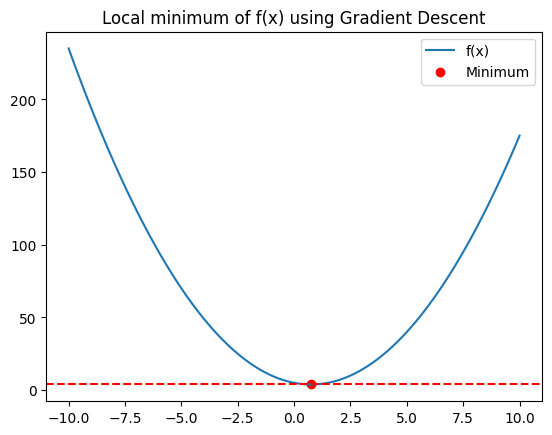

In [14]:
plt.plot(x_values, y_values, label = "f(x)")
plt.scatter(minimum, f(minimum), label = "Minimum", color = "red")
plt.axhline(f(minimum), color="red", linestyle = "--")
plt.title("Local minimum of f(x) using Gradient Descent")
plt.legend()
plt.show()

Learning Curve Visualized

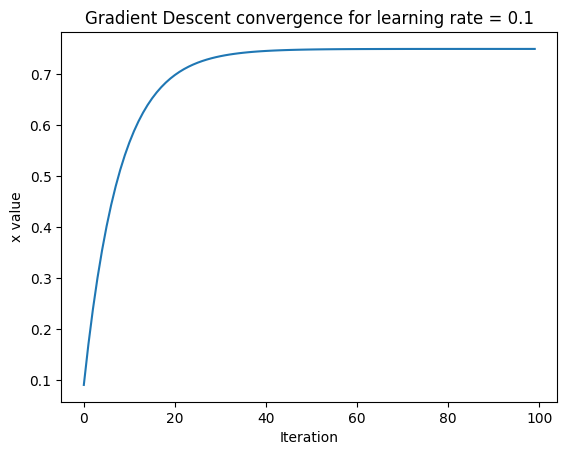

In [15]:
x = 0
lr = 0.03
iter = 100
value_of_x_per_iter = []

for iter in range(iter):
    x = x - lr * df(x)
    value_of_x_per_iter.append(x)

plt.plot(range(iter+1), value_of_x_per_iter)
plt.xlabel("Iteration")
plt.ylabel("x value")
plt.title("Gradient Descent convergence for learning rate = 0.1")
plt.show()


In [16]:
print(np.random.rand(2))

[0.58369791 0.87956197]


## Gradient Descent in Simple Linear Regression

Algorithm steps:
- Start with random initial values for the slope ($m$) and intercept ($b$) of the equation $ y = m x + b $.

- Measure the error using the Mean Squared Error:

     $\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \frac{1}{n} \sum_{i=1}^{n} (y_i - (m x + b))^2 $

- Compute the derivate of the loss function (MSE in our case) with respect to $m$ and $b$:  
    1) $\frac{\partial L}{\partial m}$ 
    
    2) $\frac{\partial L}{\partial b}$

- Update $m$ and $b$ parameters to reduce error in next iteration:  
    1)  $m = m - α\frac{\partial L}{\partial m}$

    2)  $b = b - α\frac{\partial L}{\partial b}$

- Repeat until we reach a local minimum 



### Simple Linear Regression Example

In [17]:
#Example
data = pd.read_csv("D:/Studying/Machine Learning/ML Projects/Linear-Regression/data/test.csv")
data.head(10)

,x,y
0,77,79.775152
1,21,23.177279
2,22,25.609262
3,20,17.857388
4,36,41.849864
5,15,9.805235
6,62,58.874659
7,95,97.617937
8,20,18.395127
9,5,8.746748


In [18]:
print(data.shape)

(300, 2)


In [19]:
x = data["x"]
y = data["y"]
print(x)
print(y)

0      77
1      21
2      22
3      20
4      36
       ..
295    71
296    46
297    55
298    62
299    47
Name: x, Length: 300, dtype: int64
0      79.775152
1      23.177279
2      25.609262
3      17.857388
4      41.849864
         ...    
295    68.545888
296    47.334876
297    54.090637
298    63.297171
299    52.459467
Name: y, Length: 300, dtype: float64


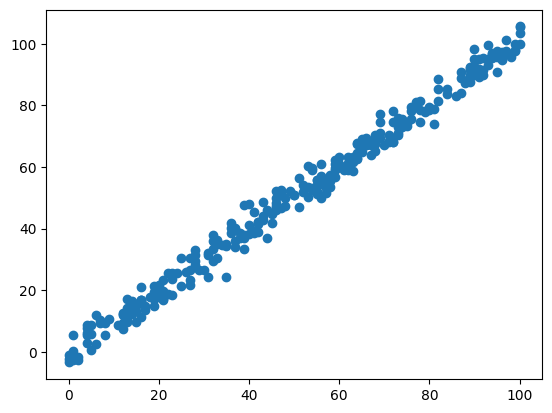

In [20]:
plt.scatter(x,y)
plt.show()

In [21]:
m = np.random.randn()
b = np.random.randn()
print(m,b)

0.7647831401399816 0.5012592461084824


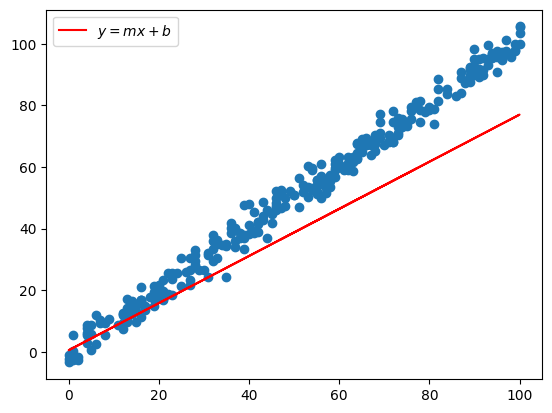

In [22]:
plt.scatter(x, y)
plt.plot(x, m*x + b, color = "red", label = "$y = mx + b$")
plt.legend()
plt.show()

#### Mean squared error function

In [47]:
def loss_function(Y, Y_pred):
    n = len(Y)
    return (1/n) * np.sum((Y - Y_pred) ** 2)

In [48]:
m = 0
b = 0
iter = 20000
lr = 0.00005
n = len(x)

# Loop over all iterations
for i in range(iter):
    y_pred = m * x + b # predictions
    # Gradients
    dM = (-2/n) * np.sum(x * (y - y_pred))
    dB = (-2/n) * np.sum(x - y_pred)
    # Compute new m & b parameters
    m = m - lr*dM
    b = b - lr*dB
    # Print loss, m and b every 1000 iterations
    if (i + 1) % 1000 == 0:
        loss = loss_function(y, y_pred)
        print(f"Iter {i+1}: Loss = {loss}, m = {m}, b = {b}")
    

Iter 1000: Loss = 9.210171153574523, m = 1.0077628909455878, b = -0.02265248882294846
Iter 2000: Loss = 9.202796953322741, m = 1.008314096494148, b = -0.05948949882627553
Iter 3000: Loss = 9.19621906833398, m = 1.0088523479741938, b = -0.09546078976583013
Iter 4000: Loss = 9.190389845012989, m = 1.0093779498236821, b = -0.13058670719890034
Iter 5000: Loss = 9.185264093920539, m = 1.0098911993258706, b = -0.16488711853493446
Iter 6000: Loss = 9.180798969422321, m = 1.0103923867774616, b = -0.1983814242726542
Iter 7000: Loss = 9.1769538550667, m = 1.0108817956527967, b = -0.2310885689730811
Iter 8000: Loss = 9.173690254421803, m = 1.0113597027641905, b = -0.26302705197468446
Iter 9000: Loss = 9.170971687115333, m = 1.011826378418498, b = -0.29421493785670677
Iter 10000: Loss = 9.168763589832206, m = 1.0122820865700006, b = -0.32466986665658765
Iter 11000: Loss = 9.167033222036805, m = 1.012727084969701, b = -0.3544090638472661
Iter 12000: Loss = 9.16574957619732, m = 1.013161625311108, b

In [35]:
print(loss, m, b)

9.352199679437039 1.0276340668105717 -1.3506411239671343


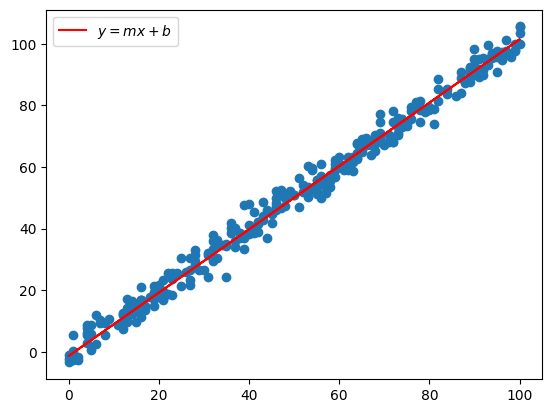

In [43]:
plt.scatter(x, y)
plt.plot(x, m*x + b, color = "red", label = "$y = mx + b$")
plt.legend()
plt.show()

In [32]:
model = SimpleLinearRegression(0.0001, 100000)

In [33]:
model.gradient_descent(x,y)

Iter 0: Loss = 3464.291087139079, m = 0.6859218356105947, b = 0.010241010219655334
Iter 1000: Loss = 9.21347440903761, m = 1.0075313846655738, b = -0.0071021294376294964
Iter 2000: Loss = 9.20901101885472, m = 1.0078474352479911, b = -0.028223757288574063
Iter 3000: Loss = 9.204952655098026, m = 1.0081488049949576, b = -0.04836426641934217
Iter 4000: Loss = 9.20126256399983, m = 1.0084361758445601, b = -0.06756923068200019
Iter 5000: Loss = 9.19790732698084, m = 1.0087101980582447, b = -0.08588210698196004
Iter 6000: Loss = 9.19485655800142, m = 1.0089714916922248, b = -0.10334433361206691
Iter 7000: Loss = 9.192082628376454, m = 1.009220648000542, b = -0.11999542401897802
Iter 8000: Loss = 9.189560416561598, m = 1.0094582307729523, b = -0.1358730562140097
Iter 9000: Loss = 9.187267080645018, m = 1.009684777610668, b = -0.15101315803076926
Iter 10000: Loss = 9.185181851484131, m = 1.0099008011428392, b = -0.16544998842249362
Iter 11000: Loss = 9.183285844613977, m = 1.0101067901865273,

In [34]:
model.predict(x)

0      77.641388
1      20.842043
2      21.856317
3      19.827769
4      36.056153
         ...    
295    71.555744
296    46.198893
297    55.327359
298    62.427278
299    47.213167
Name: x, Length: 300, dtype: float64